## Imports

In [42]:
import statsmodels as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.main import get_data

## EDA

[*********************100%***********************]  1 of 1 completed


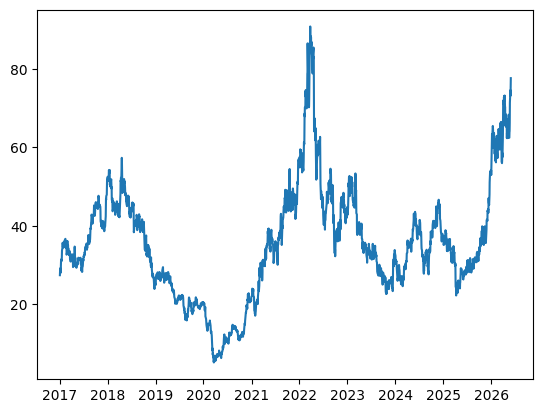

In [43]:
from src.indicators import calc_adx, calc_log_rt, calc_rvol

data = get_data(["AA"], "2017-01-01", "2026-06-01")


data.columns = data.columns.droplevel(1)

adx = calc_adx(data["High"], data["Low"], data["Close"])["adx"]

close = data["Close"]
volume = data["Volume"]
plt.plot(close)
plt.show()

from src.indicators import calc_macd, rolling_zscore

macd = calc_macd(closing=close)
z_score = rolling_zscore(macd["histogram"], 20)

log_return = calc_log_rt(close)
realized_vol = calc_rvol(log_return)



df = pd.DataFrame({
    "close": close,
    "adx": adx,
    "volume": volume,
    "log_close": np.log(close),
    "macd": macd["histogram"],
    "z_score": z_score,
    "rvol": realized_vol,
    "log_return": log_return
})

In [44]:
df

,close,adx,volume,log_close,macd,z_score,rvol,log_return
Date,,,,,,,,
2017-01-03,27.448816,NaN,2746400,3.312323,0.000000,NaN,NaN,NaN
2017-01-04,28.810305,100.000000,3339500,3.360733,0.086887,NaN,NaN,0.048410
2017-01-05,29.181623,100.000000,2444600,3.373539,0.160290,NaN,NaN,0.012806
2017-01-06,29.210186,100.000000,2086300,3.374517,0.199154,NaN,NaN,0.000978
2017-01-09,28.067675,94.681126,4205100,3.334619,0.139144,NaN,NaN,-0.039899
...,...,...,...,...,...,...,...,...
2026-05-22,71.379997,13.729937,6952400,4.268018,0.524423,1.765223,0.171235,0.074280
2026-05-26,74.570000,15.379474,5124400,4.311738,0.968639,2.154066,0.176882,0.043721
2026-05-27,73.150002,16.265452,3278800,4.292512,1.105641,2.015471,0.176759,-0.019226


frac_diff autocorr(1): 0.944
frac_diff autocorr(20): 0.707


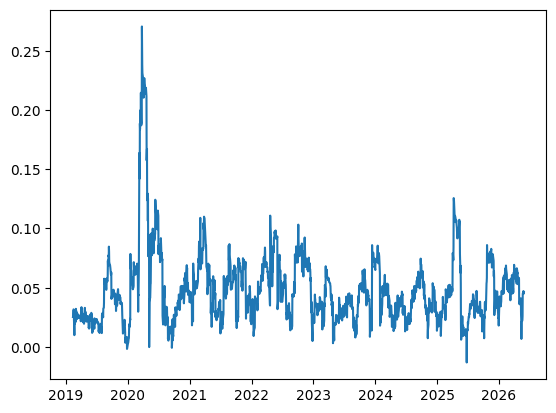

In [56]:
from src.features.frac_diff import find_d


tau=1e-3

_, fd = find_d(df["log_close"], range_list=[0.2, 0.5], alpha=0.01, max_depth=18)

rvol_5 = calc_rvol(log_return, 5)
rvol_60 = calc_rvol(log_return, 60)

rvol_ratio = rvol_5 / rvol_60

df["rvol_ratio"] = rvol_ratio



_, vol_fd = find_d(df["rvol"].dropna(), range_list=[0.2, 0.5], alpha=0.01, max_depth=18)

df["frac_diff"] = fd
df["vol_fd"] = vol_fd
print("frac_diff autocorr(1):",  df["frac_diff"].autocorr(1).round(3))
print("frac_diff autocorr(20):", df["frac_diff"].autocorr(20).round(3))

plt.plot(vol_fd)
plt.show()

## Feature Engineering

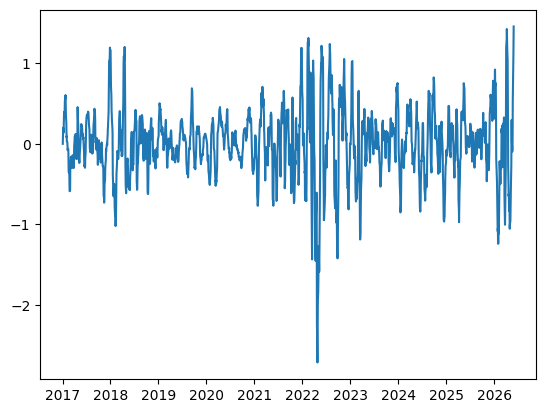

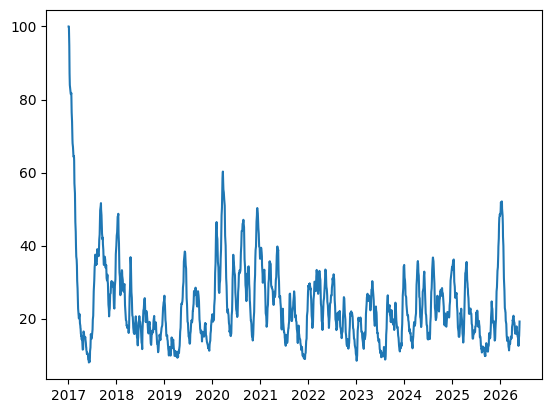

In [57]:
plt.plot(df["macd"])
plt.show()

plt.plot(df["adx"])
plt.show()


_, macd_fd = find_d(df["macd"], tau, max_depth=12)
_, adx_fd = find_d(df["adx"], tau, max_depth=12)

In [58]:
from sklearn.preprocessing import StandardScaler


rvol_5 = calc_rvol(log_return, 5)
rvol_60 = calc_rvol(log_return, 60)

rvol_ratio = rvol_5 / rvol_60

df["rvol_ratio"] = rvol_ratio



volume_trailing = df["volume"] / df["volume"].rolling(20).mean()

df["volume_trailing"] = volume_trailing
df["vol_skew"] = df["close"].pct_change().rolling(30).skew()
df_clean = df.dropna()


features = pd.concat({
    "macd": df_clean["macd"],
    # "macd_fd": macd_fd,
    # "adx_fd": adx_fd,
    "frac_diff": df_clean["frac_diff"],  # direction
    # "log_return": df_clean["log_return"],
    "adx": df_clean["adx"],
    # "rvol": np.log(df_clean["rvol"]),
    # "vol_ratio": df_clean["rvol_ratio"]
    # "vol_fd": df_clean["vol_fd"],                     # volatility (normalized)
    # "volume_trailing": np.log(df_clean["volume_trailing"]),
    # "return_skewness": df_clean["vol_skew"]
}, axis=1, sort=True).dropna()


features_sliced = features["2021-01-01":"2025-12-31"]

scaler = StandardScaler()

X = scaler.fit_transform(features_sliced.values)
Y = scaler.transform(features.values)

features

,macd,frac_diff,adx
Date,,,
2019-02-11,-0.078501,0.343216,12.234366
2019-02-12,-0.049445,0.357103,12.071009
2019-02-13,0.011991,0.375493,11.342629
2019-02-14,-0.000667,0.337822,10.900291
2019-02-15,-0.003200,0.347021,10.311370
...,...,...,...
2026-05-22,0.524423,0.626025,13.729937
2026-05-26,0.968639,0.642581,15.379474
2026-05-27,1.105641,0.599410,16.265452


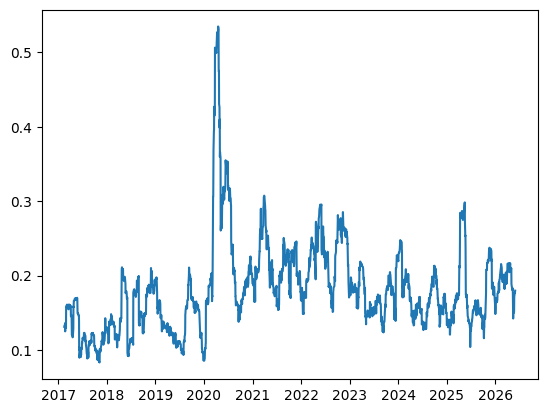

In [59]:
plt.plot(df["rvol"])

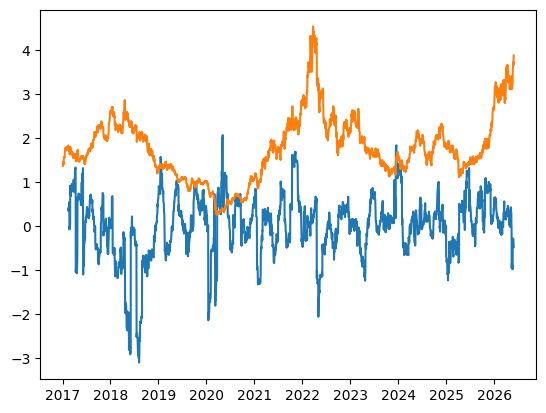

In [60]:
plt.plot(df["vol_skew"])
plt.plot(df["close"]/20.)
plt.show()

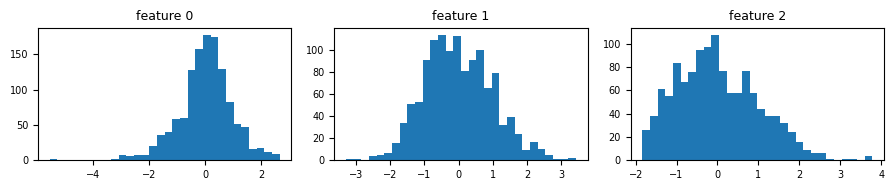

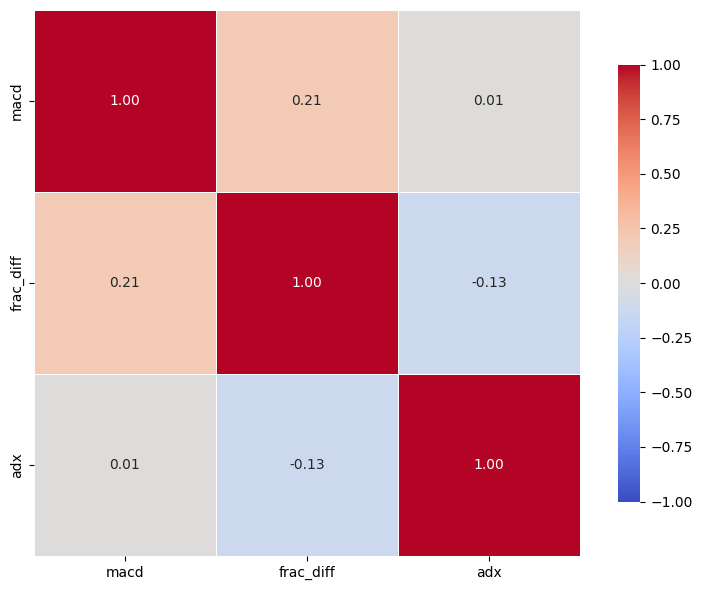

In [61]:
# compact grid of histograms for every feature
n_features = X.shape[1]
n_cols     = 4
n_rows     = -(-n_features // n_cols)  # ceil div

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols*3, n_rows*2),
                         tight_layout=True)
axes = axes.ravel()

for i in range(n_features):
    axes[i].hist(X[:, i], bins=30)
    axes[i].set_title(f"feature {i}", fontsize=9)
    axes[i].tick_params(labelsize=7)

# hide unused axes
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)


plt.show()


import matplotlib.pyplot as plt
import seaborn as sns

corr = features.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
plt.tight_layout()
plt.show()

## Training

In [62]:
from pathlib import Path

from hmmlearn.hmm import GaussianHMM

fwd = close.loc[features.index].pct_change().shift(-1).reindex(features.index)

import numpy as np
from hmmlearn.hmm import GaussianHMM

best_model = None
best_bic = np.inf
best_n = None
results = {}

for i in range(2, 6):
    
    model = GaussianHMM(
        n_components=3,
        covariance_type="full",
        random_state=np.random.randint(1, 1222),
        n_iter=100,
        min_covar=1e-2,
    )
    model.fit(X)

    bic = model.bic(X)
    results[i] = bic

    if bic < best_bic:
        best_bic = bic
        best_model = model
        best_n = i

print(f"Best: n_components={best_n}, BIC={best_bic:.2f}")

Best: n_components=2, BIC=8451.87


In [63]:
# import matplotlib.pyplot as plt
# from collections import defaultdict

# bic_by_n = defaultdict(list)

# for model in result["models"]:
#     bic_by_n[model["n_components"]].append(model["bic"])

# cmap = plt.get_cmap("tab10")
# for i, (n, bics) in enumerate(sorted(bic_by_n.items())):
#     plt.plot(bics, color=cmap(i), label=f"n_components={n}")

# plt.xlabel("model index (within n_components)")
# plt.ylabel("BIC")
# plt.legend()
# plt.show()

## Results

In [64]:
features.columns.to_list()

['macd', 'frac_diff', 'adx']

In [65]:
# save_model = best_model


# import joblib
# import json
# joblib.dump(save_model, "./models/vol_regime/model.pkl")
# joblib.dump(scaler, "./models/vol_regime/scaler.pkl")

# import json

# with open("./models/vol_regime/metadata.json", "w") as f:
#     json.dump({"features":features.columns.to_list()}, f)

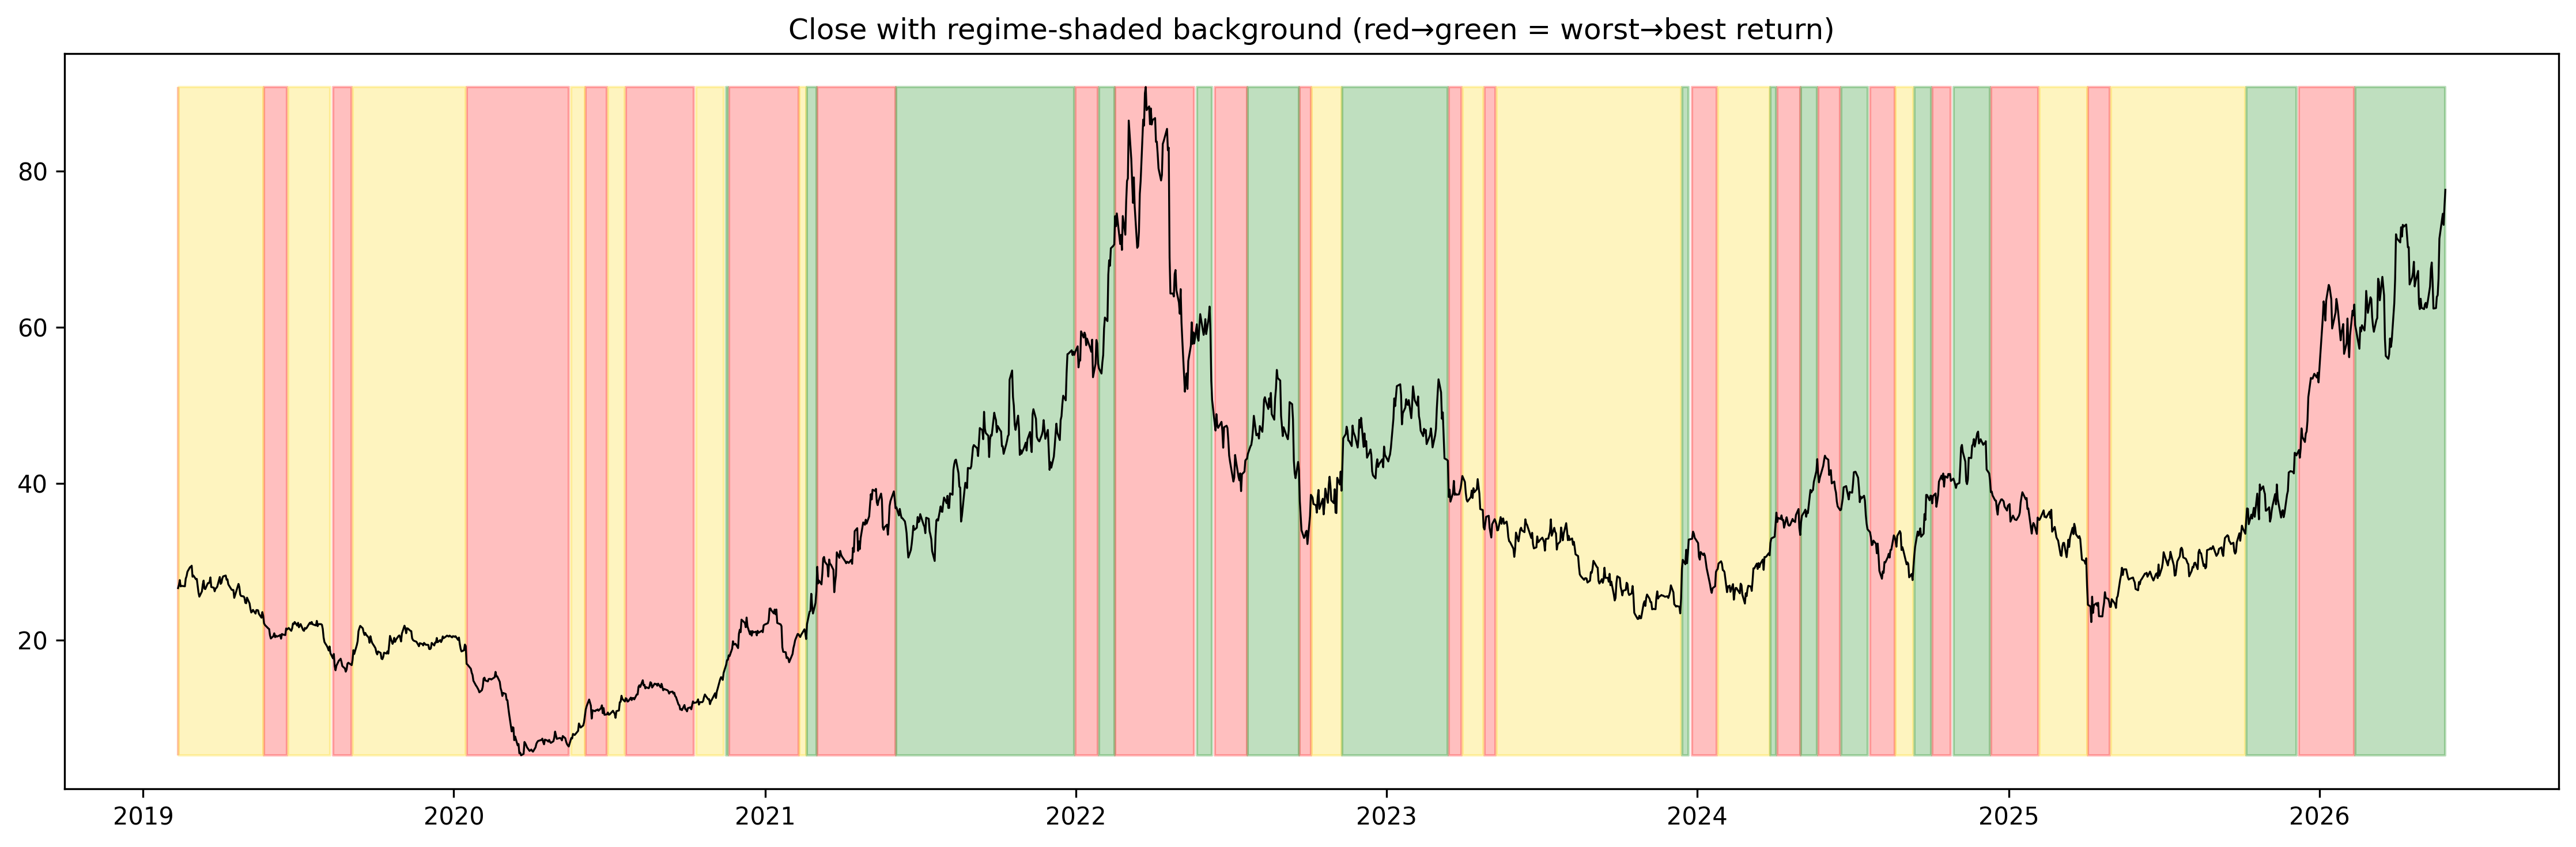

In [66]:
preds = best_model.predict(Y)

import matplotlib.colors as mcolors

price = df["close"].loc[features.index].values.flatten()

df_val = pd.DataFrame({
    'regime': preds.squeeze(),
    'next_return': close.loc[features.index].pct_change().shift(-1).values.squeeze()
}, index=features.index)

ramp = mcolors.LinearSegmentedColormap.from_list("regime", ["red", "gold", "green"])
palette = [ramp(i / (best_model.n_components - 1))
           for i in range(best_model.n_components)]

means = [df_val[df_val.regime == r].next_return.mean()
         for r in range(best_model.n_components)]



order = np.argsort(means)
remap = {old: new for new, old in enumerate(order)}
preds_sorted = np.array([remap[r] for r in preds])

fig, ax = plt.subplots(figsize=(15, 5), dpi=300)

ax.plot(features.index, price, color="black", lw=0.8)

for r in range(best_model.n_components):
    mask = preds_sorted == r
    ax.fill_between(
        features.index,
        price.min(),
        price.max(),
        where=mask,
        color=palette[r],
        alpha=0.25,
        step="mid"
    )

ax.set_title("Close with regime-shaded background (red→green = worst→best return)")

plt.tight_layout()
plt.show()